In [163]:
import pandas as pd
import numpy as np

In [164]:
from pytrends.request import TrendReq ###-----> Google Trend'ten veri çekmek 

### Google Trends sorgu için nesle oluşturuldu

In [165]:
pytrends = TrendReq(
    hl ="tr-TR",
    tz=0
)

In [166]:
keywords = ["Python", "SQL"]

In [167]:
pytrends.build_payload(      ### build_payload ---> Google Trends'ten veri çekmek için gerekli parametreleri ayarlıyor.
    kw_list=keywords,
    cat=0,    ## cat --> 0 = tüm kategoriler, 1 = iş ve endüstri, 2 = finans, 3 = sağlık, 4 = bilim ve teknoloji, 5 = spor, 6 = seyahat, 7 = eğlence, 8 = haberler ve politika, 9 = alışveriş ve moda
    timeframe="2023-08-11 2026-08-11",
    geo="",
    gprop=""
)

In [168]:
df = pytrends.interest_over_time()  ###---> Gerçek veri çekiliyor ve DataFrame'e aktarılıyor

In [169]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 158 entries, 2023-08-06 to 2026-08-09
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Python     158 non-null    int64
 1   SQL        158 non-null    int64
 2   isPartial  158 non-null    bool 
dtypes: bool(1), int64(2)
memory usage: 3.9 KB


In [170]:
df.head()

,Python,SQL,isPartial
date,,,
2023-08-06,62,31,False
2023-08-13,62,30,False
2023-08-20,66,30,False
2023-08-27,67,29,False
2023-09-03,68,29,False


In [171]:
df.tail()

,Python,SQL,isPartial
date,,,
2026-07-12,58,20,False
2026-07-19,61,25,False
2026-07-26,62,20,False
2026-08-02,57,18,False
2026-08-09,48,17,False


In [172]:
df.shape

(158, 3)

In [173]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 158 entries, 2023-08-06 to 2026-08-09
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Python     158 non-null    int64
 1   SQL        158 non-null    int64
 2   isPartial  158 non-null    bool 
dtypes: bool(1), int64(2)
memory usage: 3.9 KB


In [174]:
df.to_csv(
    "../data/raw/langchain_global_raw.csv"
)

In [175]:
df.index.min()

Timestamp('2023-08-06 00:00:00')

In [176]:
df.index.max()

Timestamp('2026-08-09 00:00:00')

In [177]:
pd.infer_freq(df.index) ### ----> Verinin haftalık olduğu bulundu W --> Weekly / SUN --> Sunday

'W-SUN'

In [178]:
df.index.to_series().diff().value_counts() ### Doğrulama işlemi 

date
7 days    157
Name: count, dtype: int64

In [179]:
df.isnull().sum()  ### NaN kontrolü ama tarih kayıp ise yetersiz işlem

Python       0
SQL          0
isPartial    0
dtype: int64

In [180]:
df.index.duplicated().sum() ### Tarih tekrarı kontrolü

np.int64(0)

In [181]:
trends=["Python", "SQL"]

In [182]:
(df[trends] == 0).sum()

Python    0
SQL       0
dtype: int64

In [183]:
df[trends].describe()

,Python,SQL
count,158.000000,158.000000
mean,65.189873,25.968354
std,9.862205,3.887627
min,40.000000,12.000000
25%,60.000000,24.000000
50%,65.000000,26.000000
75%,68.000000,29.000000
max,100.000000,35.000000


In [184]:
df.to_csv(
    "../data/raw/langchain_global_raw.csv"
)

In [185]:
### teorik olarak olması gereken tarih takvimi oluşturuldu çünkü eksik tarih verisini daha basit gözlemyebilmek için
full_index = pd.date_range(    ### date_range --> düzenli tarih dizisi oluşturur
    start=df.index.min(),
    end=df.index.max()
)

full_index

DatetimeIndex(['2023-08-06', '2023-08-07', '2023-08-08', '2023-08-09',
               '2023-08-10', '2023-08-11', '2023-08-12', '2023-08-13',
               '2023-08-14', '2023-08-15',
               ...
               '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03',
               '2026-08-04', '2026-08-05', '2026-08-06', '2026-08-07',
               '2026-08-08', '2026-08-09'],
              dtype='datetime64[s]', length=1100, freq='D')

In [186]:
freq = pd.infer_freq(df.index) ### Zaman serisinin hangi frekansta ilerlediğini otomatik tespit ediyoruz

print("Tespit edilen frekans:", freq)

Tespit edilen frekans: W-SUN


In [187]:
### Veri setinin ilk ve son atrihi arasında buluması gereken tüm haftalık tarihleri oluşturuyoruz
### Amaç ise Gerçek veri içerisinde tamamen kayıp olan bir hafta varsa daha sonra buun tespit edebilmek

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq=freq
)

In [188]:
expected_count = len(full_index) ### teorik olarak bu zaman aralığında 158 hafta gözlem olması gerekiyor
print("Beklenen gözlem sayısı:", expected_count)

Beklenen gözlem sayısı: 158


In [189]:
actual_count = len(df) ### Google Trend'ten çektiğimiz gerçek gözlem sayısını kontrol ediyoruz ama hala yeterli dğeil
print("gerçek gözlem sayısı:", actual_count)

gerçek gözlem sayısı: 158


## Neden hala yeterli değil ? 

##### " 1 Ocak, 8 Ocak, 15 Ocak, 22 Ocak " olması gerekirken gerçek veri " 1 Ocak, 8 Ocak, 22 Ocak, 29 ocak " 

##### Her ikisinde de 4 tarih var ama 15 Ocak eksik, 29 Ocak ise fazladan





In [190]:
### difference() -----> full index - gerçek index = eksik tarihler
missing_count = full_index.difference(df.index)  

In [191]:
missing_count

DatetimeIndex([], dtype='datetime64[s]', freq='W-SUN')

In [192]:
print("Eksik tarih sayısı:", len(missing_count))

Eksik tarih sayısı: 0


## Interpolation ----> bilinen değerlerden bilinmeyeni tahmin etme yöntemi


#### Zaman serisinin haftalık frekansı kontrol edildi ve eksik timestamp tespit edilmedi. Bu nedenle interpolation uygulanmadı.

#### Ama eğer eksik değer herhangi bir hafta eksik olsaydı, o tarihte NaN değeri oluşacaktı. Bu yüzden zaman bazlı interpolation uyguluyoruz. Eksik değer yoksa veri üzerinde herhangi bir değişiklik yapmamış olacaz.




In [193]:
## interpolotion smote tekniğinden farkı nedir? Sentetik veri üretmiş oluyor sonuçta?
## interpolation uygulandıgında model kendini ezberlemez mi? yani yanıtlmaz mı?

In [194]:
trends=["Python", "SQL"]

In [195]:
## Veriyi, oluşturduğumuz düzenli haftalık tarih takvimine göre yeniden indeksliyoruz.
## Eğer gerçek veride tamamen eksik bir hafta varsa, o tarih DataFrame'e eklenir
## ve LangChain değeri NaN olarak görünür.

df_regular = df.reindex(full_index)
missing_count = df_regular[trends].isna().sum()

print("Eksik gözlem sayısı:", missing_count)

Eksik gözlem sayısı: Python    0
SQL       0
dtype: int64


In [196]:
if missing_count.sum() > 0:
    df_regular[trends] = (
        df_regular[trends]
        .interpolate(method="time")
    )
    print("Eksik değerler interpolation ile dolduruldu.")

else:
    print("Eksik zaman noktası bulunmadı. Interpolation uygulanmadı.")

Eksik zaman noktası bulunmadı. Interpolation uygulanmadı.


In [197]:
clean_df = df.copy()

In [198]:
## Google Trends'teki tamamlanmamış dönemlere bakılıyor..
## isPartial=True olan satır, ilgili haftanın henüz tamamlanmadığını gösterir.

clean_df[clean_df["isPartial"] == True]

,Python,SQL,isPartial
date,,,


In [199]:
## Tamamlanmamış haftaları temiz veri setinden çıkarıyoruz.
## Çünkü henüz tamamlanmamış bir haftanın trend değeri ileride değişebilir
## ve modelleme aşamasında yanıltıcı olabilir.

# Eğer isPartial sütunu varsa yalnızca tamamlanmış
## Google Trends gözlemlerini tutuyoruz.

if "isPartial" in df.columns:

    clean_df = clean_df[
        clean_df["isPartial"] == False
    ].copy()

    clean_df = clean_df.drop(
        columns=["isPartial"]
    )

df.tail()

,Python,SQL,isPartial
date,,,
2026-07-12,58,20,False
2026-07-19,61,25,False
2026-07-26,62,20,False
2026-08-02,57,18,False
2026-08-09,48,17,False


In [200]:
clean_df.head()

,Python,SQL
date,,
2023-08-06,62,31
2023-08-13,62,30
2023-08-20,66,30
2023-08-27,67,29
2023-09-03,68,29


In [201]:
clean_df.tail()

,Python,SQL
date,,
2026-07-12,58,20
2026-07-19,61,25
2026-07-26,62,20
2026-08-02,57,18
2026-08-09,48,17


In [202]:
clean_df.head()

,Python,SQL
date,,
2023-08-06,62,31
2023-08-13,62,30
2023-08-20,66,30
2023-08-27,67,29
2023-09-03,68,29


In [203]:
clean_df.index.name

'date'

In [204]:
clean_df.to_csv(
    "../data/processed/langchain_global_clean.csv"
)

# EDA

In [205]:
### Model kurmadan önce zaman serisinin genel davranışını inceliyoruz.
### Buradaki amaç tren skorunun zaman içerisinde nasıl değiştiğini görmek

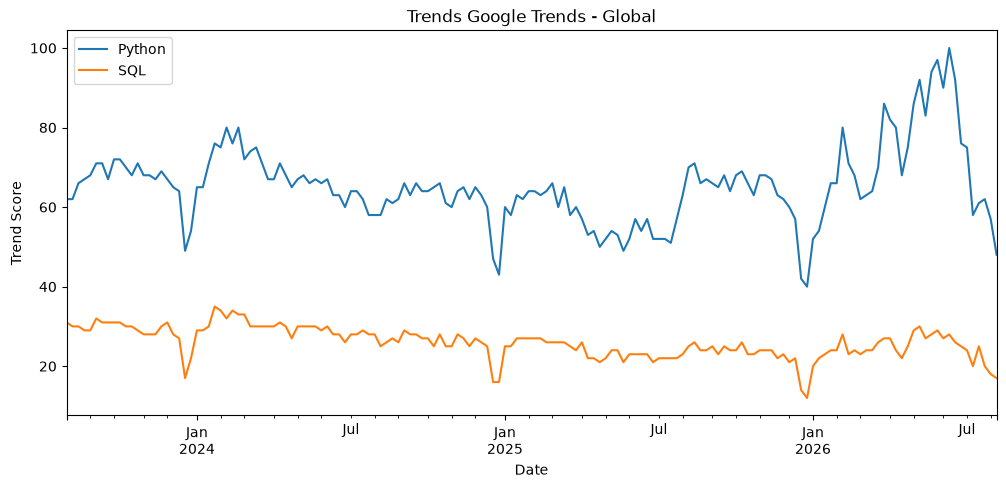

In [206]:
import matplotlib.pyplot as plt

### TrendScore sütununu tarihe göre çiziyoruz.
### Index'imiz date olduğu için x ekseni otomatik olarak tarih oluyor.

clean_df[trends].plot(figsize=(12,5))

plt.title("Trends Google Trends - Global")
plt.xlabel("Date")
plt.ylabel("Trend Score")
plt.show()

In [207]:
### Trend skorundaki kısa süreli dalgalamaları yumuşsatmak için 
### 4 haftalık hareketli ortalama(rolling mean) oluşturuyoruz
### window=4 ----> her satır için kendisi dahil son 4 haftasının ortalamasını hesaplar
### ilk üç değer Nan çıkabilir ama eksik veri problemi değil.


## 1. 5 teknoloji için 5 yeni sütun adı oluşturuyoruz (Python_rolling_4, SQL_rolling_4 vb.)
rolling_sutunlar = [f"{trend}_rolling_4" for trend in trends]

## 2. Hesaplanan 5 sütunluk tabloyu, oluşturduğumuz bu 5 yeni sütuna atıyoruz
clean_df[rolling_sutunlar] = (
    clean_df[trends]
    .rolling(window=4)
    .mean()
)


clean_df.tail()

,Python,SQL,Python_rolling_4,SQL_rolling_4
date,,,,
2026-07-12,58,20,75.25,23.75
2026-07-19,61,25,67.50,23.50
2026-07-26,62,20,64.00,22.25
2026-08-02,57,18,59.50,20.75
2026-08-09,48,17,57.00,20.00


In [208]:
### window 4 veya 8 olma etkisi 

In [209]:
clean_df.head(10)

,Python,SQL,Python_rolling_4,SQL_rolling_4
date,,,,
2023-08-06,62,31,NaN,NaN
2023-08-13,62,30,NaN,NaN
2023-08-20,66,30,NaN,NaN
2023-08-27,67,29,64.25,30.00
2023-09-03,68,29,65.75,29.50
2023-09-10,71,32,68.00,30.00
2023-09-17,71,31,69.25,30.25
2023-09-24,67,31,69.25,30.75
2023-10-01,72,31,70.25,31.25


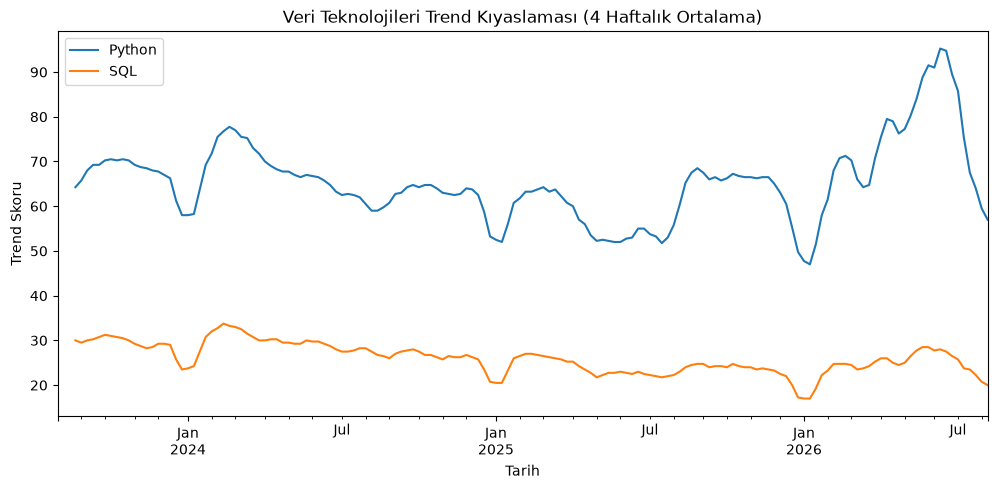

In [210]:
### Gerçek tend skoru ile 4 haftalık hareketli ortalamayı
### aynı grafik üzerinde karşılaştırıyoruz.
##
### trends -> gerçek ve daha dalgalı seri
### rolling_4   -> kısa dönem dalgalanmaları yumuşatılmış seri

## Bir önceki adımda oluşturduğumuz rolling_sutunlar listesini kullanıyoruz
## (Python_rolling_4, SQL_rolling_4, Databricks_rolling_4 vb.)

clean_df[rolling_sutunlar].plot(figsize=(12, 5))

plt.title("Veri Teknolojileri Trend Kıyaslaması (4 Haftalık Ortalama)")
plt.xlabel("Tarih")
plt.ylabel("Trend Skoru")

# Çizgilerin hangi teknolojiye ait olduğunu gösteren lejantı (kutucuğu) ayarlıyoruz
plt.legend(trends)
plt.show()

## Decomposition ----> Zaman serisi verisini analiz ederek trend (genel eğilim) ve sezonsallık (seasonality - örn: hafta sonu düşüşleri) bileşenlerine ayırmak

#### ayırmak için statsmodels kütüphanesindeki seasonal_decompose fonksiyonunu kullanıyoruz.

In [211]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [212]:
from statsmodels.tsa.seasonal import seasonal_decompose

####  Additive	             /        Multiplicative
####  Etkiler toplanır	      /       Etkiler çarpılır
####  Dalgalanma yaklaşık sabit	  /   Dalgalanma seri büyüdükçe büyür
####  Trend + Seasonal + Residual / Trend × Seasonal × Residual

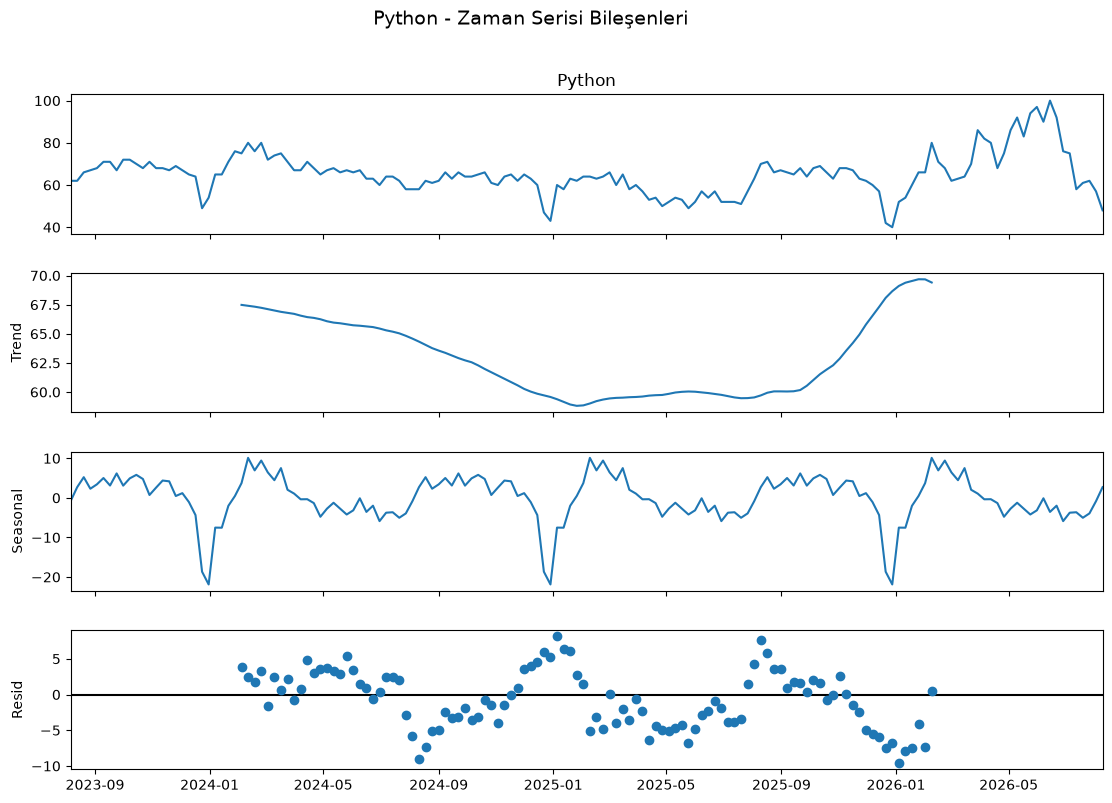

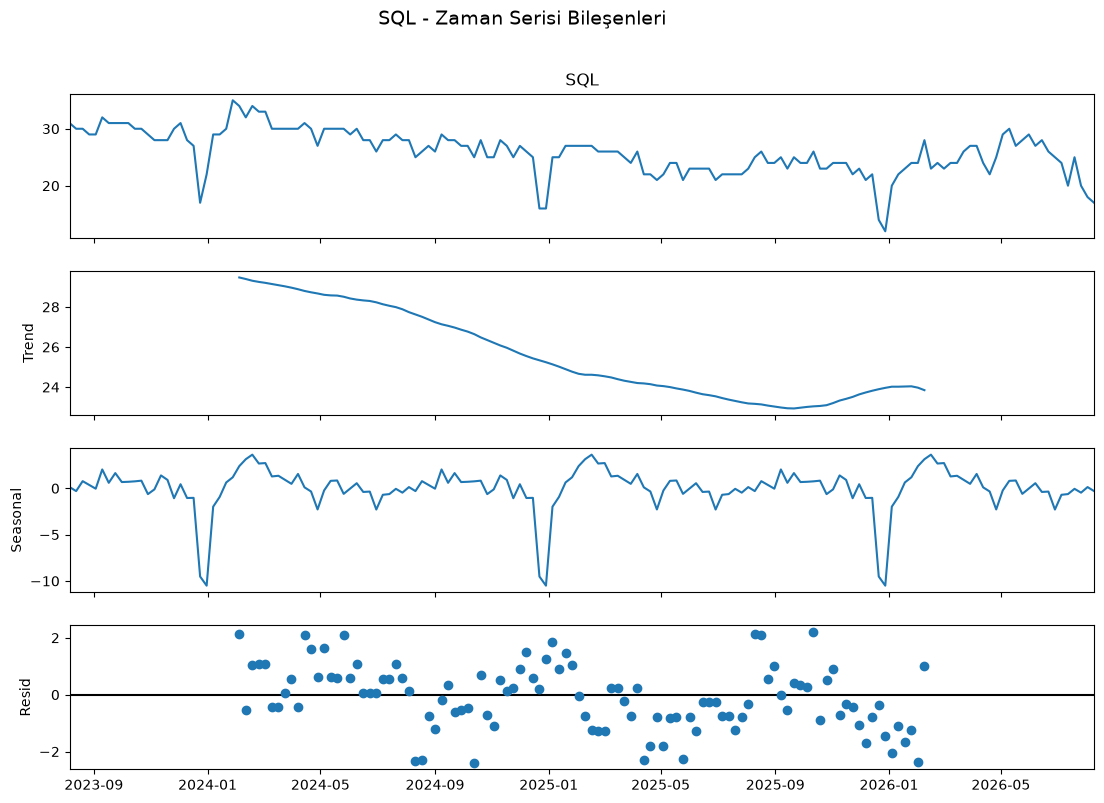

In [213]:
## Decomposition sonucunda oluşan dört bileşeni görselleştiriyoruz:
##
## Observed -> gerçek seri
## Trend    -> uzun dönemli yön
## Seasonal -> tekrar eden dönemsel yapı
## Resid    -> modelin açıklayamadığı kalan hareket

for trend in trends:

    decomposition = seasonal_decompose(
        clean_df[trend],
        model="additive",       ## Trend + Sezonsallık + Artık bileşenler
        period=52               ## Haftalık veri olduğu için yıllık döngü (52 hafta)
    )

    ## Bileşenleri görselleştiriyoruz
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle(f"{trend} - Zaman Serisi Bileşenleri", y=1.03, fontsize=14)
    plt.show()